In [11]:
import random
from dataclasses import dataclass
import numpy as np

In [12]:
@dataclass
class SimConfig:
    k: int = 4          # Number of tokens proposed per decoding step (multi-token prediction)
    p: float = 0.6      # Probability that each proposed token is correct (simplified model)
    T: int = 200        # Target total number of tokens to generate
    trials: int = 2000  # Number of simulation runs to estimate the average speedup

1) What one_step_accept_len(k, p) does

It simulates one decoding step where we propose k tokens at once, and then verify them in order.

For each of the k proposed tokens:

it is “correct” with probability p

we count how many are correct consecutively from the start

The moment we hit a wrong token, we stop (because only a correct prefix can be accepted)

It returns an integer acc in [0, k]

So yes: it’s basically “check up to k tokens, each correct with probability p, return the accepted prefix length.”

In [13]:
import random

def one_step_accept_len(k: int, p: float) -> int:
    """
    Assume we propose k tokens in one step.
    Return how many tokens are consecutively correct from the start (prefix length), in [0..k].
    """
    acc = 0  # accepted prefix length (number of consecutive correct tokens)

    for _ in range(k):  # check up to k proposed tokens in order; '_' means we don't use the loop index
        if random.random() < p:  # this token is correct with probability p
            acc += 1             # extend accepted prefix
        else:
            break                # once a token is wrong, stop (prefix must be consecutive)

    return acc

2) Then what does simulate(cfg) do?

simulate(cfg) runs the whole generation process many times (Monte Carlo) and estimates the average speedup.

Think of it as:

“How many decoding steps do we need to generate T tokens if each step can accept multiple tokens (based on one_step_accept_len)?”

Inside simulate:

Baseline assumption: normal decoding generates 1 token per step, so baseline steps = T.

For each trial (repeat cfg.trials times):

Start with produced = 0 tokens and steps = 0

While we still haven’t produced T tokens:

Do one step (steps += 1)

Get acc = one_step_accept_len(k, p) = how many tokens we can accept this step

Increase produced by max(1, acc)

if acc=0, we still move forward by 1 token (fallback), so we don’t get stuck

Store how many steps it took for that trial

After all trials:

Compute avg_steps = mean(steps_list)

Compute speedup = baseline_steps / avg_steps

In [14]:
def simulate(cfg: SimConfig):
    baseline_steps = cfg.T  # Baseline: standard decoding generates 1 token per step, so ~T steps total
    steps_list = []         # Store the number of steps needed in each trial (simulation run)

    for _ in range(cfg.trials):  # Repeat many trials to estimate the average number of steps
        produced = 0             # Number of tokens accepted/produced so far
        steps = 0                # Number of decoding steps used in this trial

        while produced < cfg.T:  # Keep going until we reach T produced tokens
            steps += 1           # Perform one decoding step
            acc = one_step_accept_len(cfg.k, cfg.p)  # Accepted prefix length (0..k) for this step

            # If acc == 0, we still advance by 1 token as a fallback (to avoid getting stuck)
            produced += max(1, acc)

        steps_list.append(steps)  # Record total steps used for this trial

    steps_arr = np.array(steps_list)            # Convert to numpy array for easy statistics
    speedup = baseline_steps / steps_arr.mean() # Speedup = baseline steps divided by average steps

    return {
        "avg_steps": steps_arr.mean(),      # Average number of steps across trials
        "baseline_steps": baseline_steps,   # Baseline steps (= T)
        "speedup": speedup,                # Estimated speedup factor
        "steps_std": steps_arr.std()        # Standard deviation of steps across trials
    }

cfg = SimConfig(k=4, p=0.6, T=200, trials=5000)  # Example configuration for the simulation

simulate(cfg)

{'avg_steps': 117.6312,
 'baseline_steps': 200,
 'speedup': 1.7002291908949325,
 'steps_std': 6.825832297969238}

In [15]:
def grid():
    rows = []  # Collect results as tuples: (k, p, avg_steps, speedup)

    # Try different proposal lengths (k) and correctness probabilities (p)
    for k in [2, 4, 6, 8]:
        for p in [0.3, 0.5, 0.7, 0.85]:
            cfg = SimConfig(k=k, p=p, T=200, trials=3000)  # Build a config for this (k, p) setting
            out = simulate(cfg)                            # Run the simulation
            rows.append((k, p, out["avg_steps"], out["speedup"]))  # Save key metrics

    return rows  # Return a list of results for all (k, p) combinations

rows = grid()          # Run the parameter sweep
rows[:5], len(rows)    # Preview first 5 rows + total number of experiments

([(2, 0.3, 183.62333333333333, 1.0891861963802711),
  (2, 0.5, 160.24166666666667, 1.2481148265640438),
  (2, 0.7, 134.39466666666667, 1.4881542918369777),
  (2, 0.85, 116.37733333333334, 1.7185477126129944),
  (4, 0.3, 178.07433333333333, 1.123126484632822)],
 16)

In [16]:
import pandas as pd

df = pd.DataFrame(rows, columns=["k", "p", "avg_steps", "speedup"])
df.sort_values(["k","p"])

,k,p,avg_steps,speedup
0,2,0.30,183.623333,1.089186
1,2,0.50,160.241667,1.248115
2,2,0.70,134.394667,1.488154
3,2,0.85,116.377333,1.718548
4,4,0.30,178.074333,1.123126
5,4,0.50,139.341333,1.435324
6,4,0.70,96.886333,2.064275
7,4,0.85,70.240000,2.847380
8,6,0.30,177.317000,1.127923
9,6,0.50,135.404333,1.477058


In [17]:
df.pivot(index="p", columns="k", values="speedup").round(2)

k,2,4,6,8
p,,,,
0.30,1.09,1.12,1.13,1.13
0.50,1.25,1.44,1.48,1.49
0.70,1.49,2.06,2.34,2.48
0.85,1.72,2.85,3.65,4.22


In [18]:
from collections import Counter

def accept_hist(k=4, p=0.6, n=20000):
    c = Counter(one_step_accept_len(k,p) for _ in range(n))
    return {a: c[a]/n for a in range(k+1)}

accept_hist(k=4, p=0.6)

{0: 0.4072, 1: 0.24035, 2: 0.14095, 3: 0.08605, 4: 0.12545}

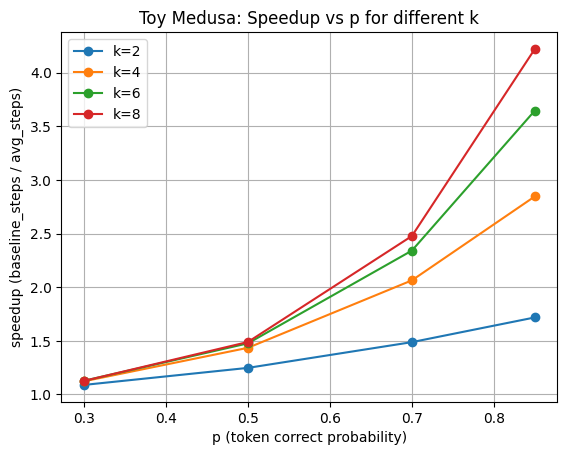

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# rows가 이미 있으면 이 부분은 생략 가능
df = pd.DataFrame(rows, columns=["k", "p", "avg_steps", "speedup"])

# p 오름차순으로 정렬
df = df.sort_values(["k", "p"])

plt.figure()
for k in sorted(df["k"].unique()):
    sub = df[df["k"] == k]
    plt.plot(sub["p"], sub["speedup"], marker="o", label=f"k={k}")

plt.xlabel("p (token correct probability)")
plt.ylabel("speedup (baseline_steps / avg_steps)")
plt.title("Toy Medusa: Speedup vs p for different k")
plt.legend()
plt.grid(True)
plt.show()
